In [42]:
import numpy as np
from scipy import constants as const
import matplotlib.pyplot as plt
import pandas as pd

# Parameters: $c_{200}$, $M_{200}$, $r_c$, $n$, $r_t$, $\delta$

In [43]:
#PARAMETERS

# c_200 = concentration parameter = R_vir/r_s
# M_200 = Mass within R_200 in solar masses
# r_c = core radius in kpc
# n = coredness parameter 0 <= n <= 1
# r_t = truncation radius in kpc
# delta = logarithmic slope parameter



c_200 = 25.690207
M_200 = 3.57964808148399e8 # Solar masses
r_c = 0.012570 # kpc
n = 0.407461
r_t = 1.857991 # kpc
delta = 3.729259



#CONSTANTs
pi = const.pi
G = const.G 
M_sun = 2e30  # kg

#CALCULATIONS

rho_crit = 136.05  # Solar masses/kpc^3
g_c = 1/(np.log10(1 + c_200) - c_200/(1 + c_200))
r_200 = (3 * M_200 / (4 * pi * 200 * rho_crit))**(1/3)
r_s = r_200/c_200


In [44]:
r99 = 20.743367613524313  # kpc

r_tot = np.logspace(-4, np.log10(r99), 1000)  # kpc

r_to_rt = np.logspace(-4, np.log10(r_t), 500)  # kpc

rt_to_end = np.logspace(np.log10(r_t), np.log10(r99), 500)  # kpc

def rho_NFW(r, rho_crit, c_200, g_c, r_s):
    return rho_crit * 200 * c_200**3 * g_c / (3 * ((r/r_s) * (1 + r/r_s)**2))

def M_NFW(r, M_200, g_c, r_s):
    return M_200 * g_c * (np.log(1 + r/r_s) - r/r_s / (1 + r/r_s))

def f(r, r_c):
    return np.tanh(r/r_c)

def M_cNFW(r, M_NFW, f, n):
    return M_NFW * f**n

def rho_cNFW(r, rho_NFW, f, n, r_c, M_NFW):
    return f**n*rho_NFW + n*f**(n-1)*(1 - f**2)/(4*pi*r_c*r**2)*M_NFW

def M_cNFWt(M_cNFW_rt, rho_cNFW_rt, r_t, delta, rt_to_end):
    return M_cNFW_rt + 4*pi*rho_cNFW_rt*r_t**(3 - delta) * ((rt_to_end/r_t)**(3-delta) -1)

def rho_cNFWt(rho_cNFW_rt, r_t, delta, rt_to_end):
    return rho_cNFW_rt * (rt_to_end/r_t)**(-delta)


# Plotting regular NFW

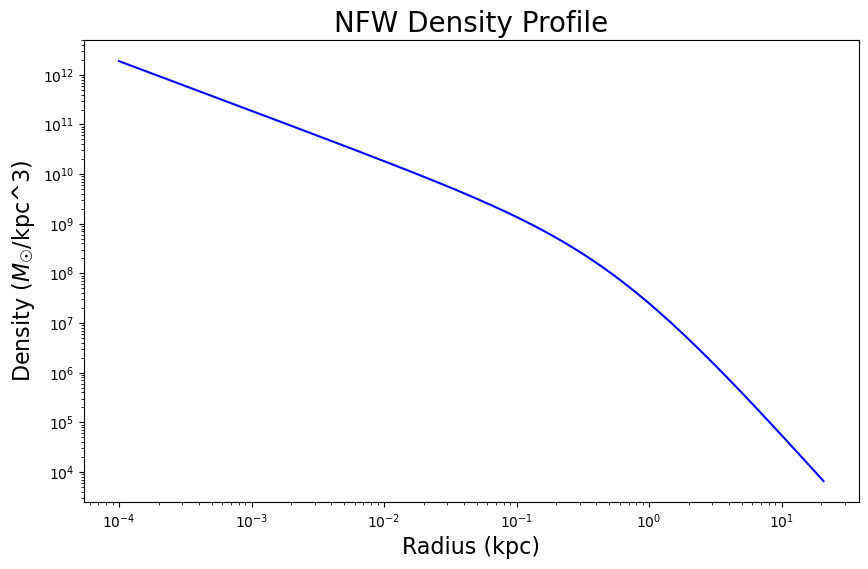

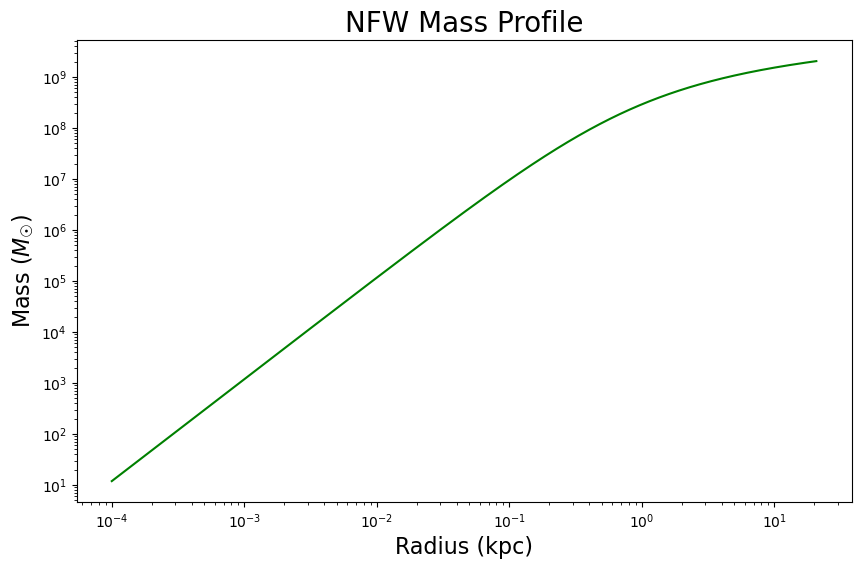

In [45]:
r = r_tot


rho_NFW_plot = rho_NFW(r, rho_crit, c_200, g_c, r_s)

plt.figure(figsize=(10, 6))
plt.title('NFW Density Profile', fontsize=20)
plt.plot(r, rho_NFW_plot, label='NFW Density Profile', color='blue')
plt.yscale('log')
plt.xscale('log')
plt.xlabel('Radius (kpc)', fontsize=16)
plt.ylabel('Density ($M_\u2609$/kpc^3)', fontsize=16)
plt.show()

M_NFW_plot = M_NFW(r, M_200, g_c, r_s)

plt.figure(figsize=(10, 6))
plt.title('NFW Mass Profile', fontsize=20)
plt.plot(r, M_NFW_plot, label='NFW Mass Profile', color='green')
plt.xlabel('Radius (kpc)', fontsize=16)
plt.ylabel('Mass ($M_\u2609$)', fontsize=16)
plt.yscale('log')
plt.xscale('log')
plt.show()


# Cored NFW

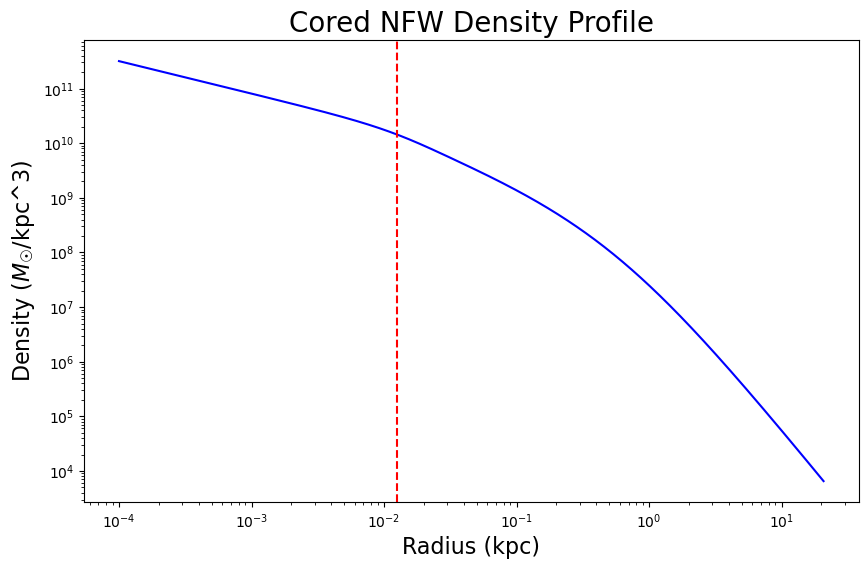

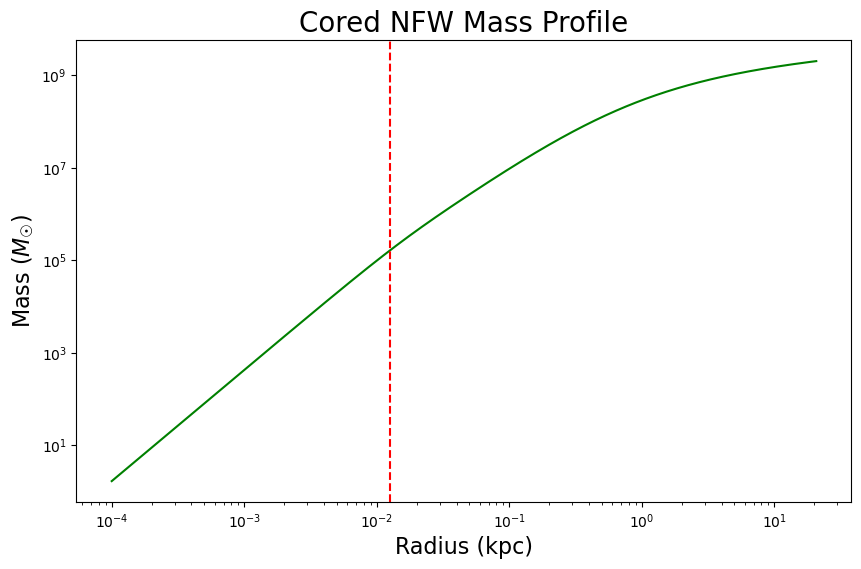

In [46]:
r = r_tot

rho_cNFW_plot = rho_cNFW(r, rho_NFW(r, rho_crit, c_200, g_c, r_s), f(r, r_c), n, r_c, M_NFW(r, M_200, g_c, r_s))

plt.figure(figsize=(10, 6))
plt.title('Cored NFW Density Profile', fontsize=20)
plt.plot(r, rho_cNFW_plot, label='Cored NFW Density Profile', color='blue')
plt.axvline(x=r_c, color='red', linestyle='--', label='Core Radius r_c')
plt.yscale('log')
plt.xscale('log')
plt.xlabel('Radius (kpc)', fontsize=16)
plt.ylabel('Density ($M_\u2609$/kpc^3)', fontsize=16)
plt.show()

M_cNFW_plot = M_cNFW(r, M_NFW(r, M_200, g_c, r_s), f(r, r_c), n)

plt.figure(figsize=(10, 6))
plt.title('Cored NFW Mass Profile', fontsize=20)
plt.plot(r, M_cNFW_plot, label='Cored NFW Mass Profile', color='green')
plt.axvline(x=r_c, color='red', linestyle='--', label='Core Radius r_c')
plt.xlabel('Radius (kpc)', fontsize=16)
plt.ylabel('Mass ($M_\u2609$)', fontsize=16)
plt.yscale('log')
plt.xscale('log')
plt.show()


# Cored and Truncated NFW

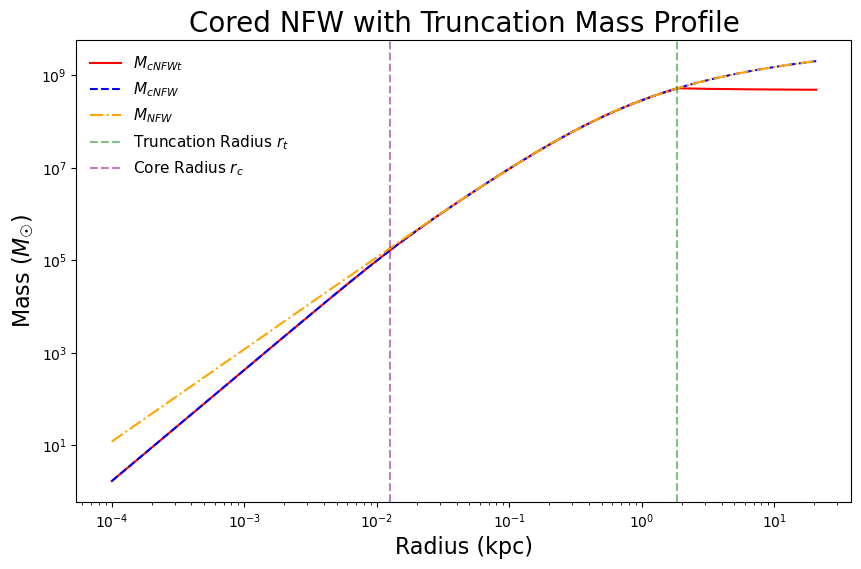

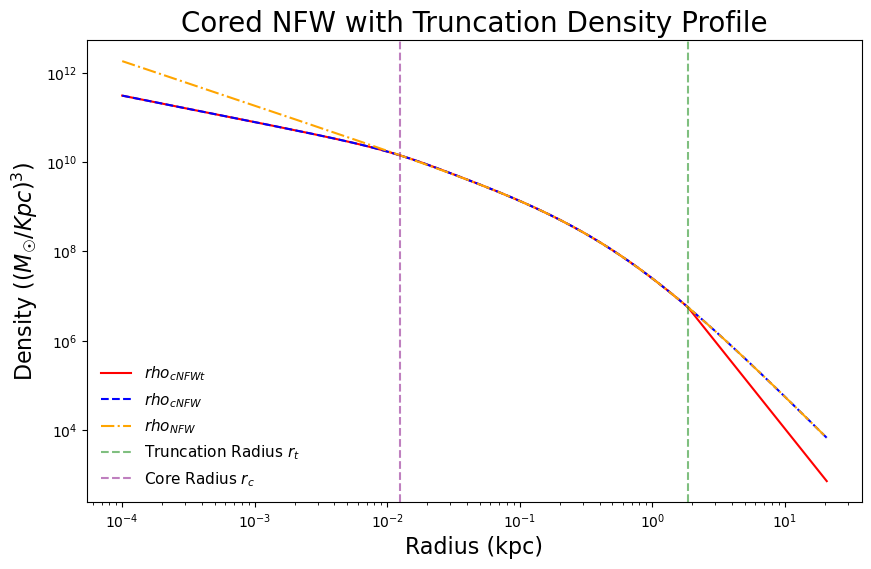

In [47]:
r = r_to_rt

M_cNFWt_plot_first = M_cNFW(r, M_NFW(r, M_200, g_c, r_s), f(r, r_c), n)

M_cNFWt_plot_last = M_cNFWt(M_cNFW(r_t, M_NFW(r_t, M_200, g_c, r_s), f(r_t, r_c), n), rho_cNFW(r_t, rho_NFW(r_t, rho_crit, c_200, g_c, r_s), f(r_t, r_c), n, r_c, M_NFW(r_t, M_200, g_c, r_s)), r_t, delta, rt_to_end)


plt.figure(figsize=(10, 6))
plt.title('Cored NFW with Truncation Mass Profile', fontsize=20)
plt.plot(r_to_rt, M_cNFWt_plot_first, label='$M_{cNFWt}$', color='red')
plt.plot(rt_to_end, M_cNFWt_plot_last, color='red')
plt.plot(r_tot, M_cNFW_plot, label='$M_{cNFW}$', color='blue', linestyle='--')
plt.plot(r_tot, M_NFW_plot, label='$M_{NFW}$', color='orange', linestyle='-.')
plt.axvline(x=r_t, color='green', linestyle='--', label='Truncation Radius $r_t$', alpha = 0.5)
plt.axvline(x=r_c, color='purple', linestyle='--', label='Core Radius $r_c$', alpha = 0.5)
plt.xlabel('Radius (kpc)', fontsize=16)
plt.ylabel('Mass ($M_\u2609$)', fontsize=16)
plt.yscale('log')
plt.xscale('log')
plt.legend(fontsize = 11, frameon = False)
plt.show()



r = r_to_rt

rho_cNFWt_plot_first = rho_cNFW(r, rho_NFW(r, rho_crit, c_200, g_c, r_s), f(r, r_c), n, r_c, M_NFW(r, M_200, g_c, r_s))

rho_cNFWt_plot_last = rho_cNFWt(rho_cNFW(r_t, rho_NFW(r_t, rho_crit, c_200, g_c, r_s), f(r_t, r_c), n, r_c, M_NFW(r_t, M_200, g_c, r_s)), r_t, delta, rt_to_end)

plt.figure(figsize=(10, 6))
plt.title('Cored NFW with Truncation Density Profile', fontsize=20)
plt.plot(r_to_rt, rho_cNFWt_plot_first, label='$rho_{cNFWt}$', color='red')
plt.plot(rt_to_end, rho_cNFWt_plot_last, color='red')
plt.plot(r_tot, rho_cNFW_plot, label='$rho_{cNFW}$', color='blue', linestyle='--')
plt.plot(r_tot, rho_NFW_plot, label='$rho_{NFW}$', color='orange', linestyle='-.')
plt.axvline(x=r_t, color='green', linestyle='--', label='Truncation Radius $r_t$', alpha = 0.5)
plt.axvline(x=r_c, color='purple', linestyle='--', label='Core Radius $r_c$', alpha = 0.5)
plt.xlabel('Radius (kpc)', fontsize=16)
plt.ylabel('Density ($(M_\u2609/Kpc)^3$)', fontsize=16)
plt.yscale('log')
plt.xscale('log')
plt.legend(fontsize = 11, frameon = False)
plt.show()



In [48]:
import numpy as np


#param = [r_c, n, r_t, delta]

param_means = np.array([r_c, n, r_t, delta])
param_stds  = np.array([r_c*0.68, n*0.68, r_t*0.68, delta*0.68])  # 68% std deviations

n_samples = 5

# Sample from 4D Gaussian parameter space (independent distributions)
params = np.random.normal(loc=param_means, scale=param_stds, size=(n_samples, 4))


def compute_M(p):

    r_c, n, r_t, delta = p

    #CALCULATIONS
    rho_crit = 136.05  # Solar masses/kpc^3
    g_c = 1/(np.log10(1 + c_200) - c_200/(1 + c_200))
    r_200 = (3 * M_200 / (4 * pi * 200 * rho_crit))**(1/3)
    r_s = r_200/c_200

    r = r_to_rt

    M_cNFWt_plot_first = M_cNFW(r, M_NFW(r, M_200, g_c, r_s), f(r, r_c), n)

    M_cNFWt_plot_last = M_cNFWt(M_cNFWt_plot_first[-1], rho_cNFW(r_t, rho_NFW(r_t, rho_crit, c_200, g_c, r_s), f(r_t, r_c), n, r_c, M_NFW(r_t, M_200, g_c, r_s)), r_t, delta, rt_to_end)

    M_cNFWt_plot = np.concatenate((M_cNFWt_plot_first, M_cNFWt_plot_last))
    
    return M_cNFWt_plot



# --- Step 3: Evaluate M for all 5000 samples ---
M_samples = np.array([compute_M(p) for p in params])



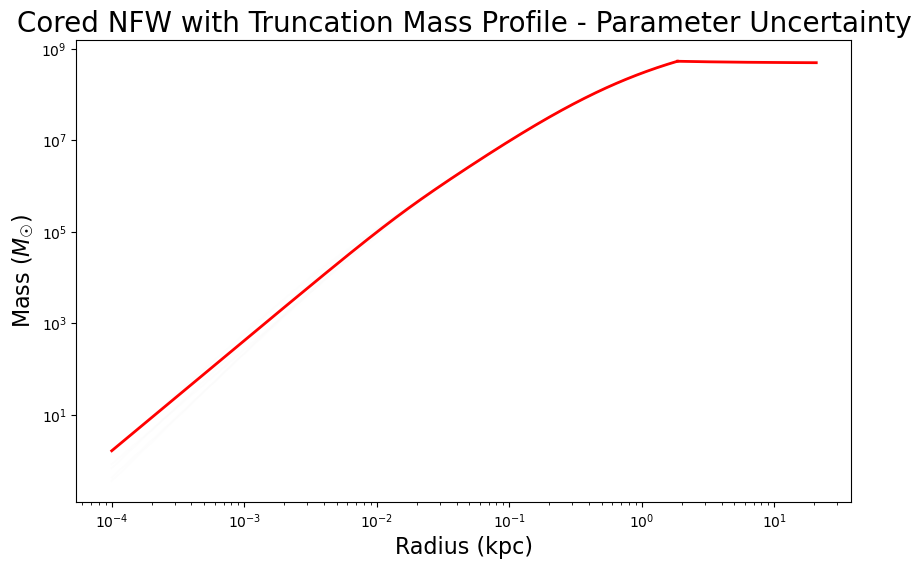

In [49]:
plt.figure(figsize=(10, 6))
plt.title('Cored NFW with Truncation Mass Profile - Parameter Uncertainty', fontsize=20)
for i in range(n_samples):
    plt.plot(r_to_rt, M_samples[i][0:500], color='gray', alpha=0.01)
    plt.plot(rt_to_end, M_samples[i][500:], color='gray', alpha=0.01)
plt.plot(r_to_rt, M_cNFWt_plot_first, label='Mean Parameters', color='red', linewidth=2)
plt.plot(rt_to_end, M_cNFWt_plot_last, color='red', linewidth=2)
plt.xlabel('Radius (kpc)', fontsize=16)
plt.ylabel('Mass ($M_\u2609$)', fontsize=16)
plt.yscale('log')
plt.xscale('log')
plt.show()

In [50]:
import numpy as np

def gauss_legendre_integral(f, r0, r1, n):
    """
    Compute ∫[r0, r1] f(r) dr using n-point Gauss–Legendre quadrature.
    
    Parameters
    ----------
    f : callable
        Function of one variable, f(r)
    r0, r1 : float
        Integration limits
    n : int
        Number of Gauss–Legendre points (controls accuracy)
    """
    # Get Gauss-Legendre nodes (x_i) and weights (w_i) on [-1, 1]
    x, w = np.polynomial.legendre.leggauss(n)
    
    # Map from [-1, 1] to [r0, r1]
    r = 0.5 * (r1 - r0) * x + 0.5 * (r1 + r0)
    dr_dx = 0.5 * (r1 - r0)
    
    # Evaluate the integral
    integral = np.sum(w * f(r)) * dr_dx
    return integral



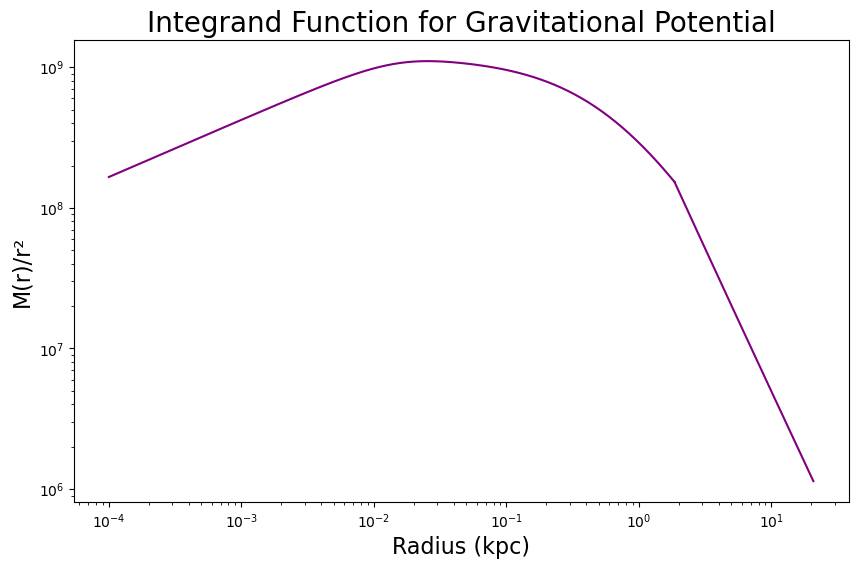

In [51]:

from scipy.interpolate import interp1d
from collections import defaultdict

m_to_kpc = 3.24078e-20  # kpc/m

total_result = defaultdict(list)


for i in range(len(M_samples)):

    f_first = interp1d(r_to_rt, M_samples[i][0:500]/((r_to_rt)**2), kind='cubic', fill_value="extrapolate")
    f_last = interp1d(rt_to_end, M_samples[i][500:]/((rt_to_end)**2), kind='cubic', fill_value="extrapolate")

    result_function = []

    for i in range(0, 500, 10):
        r0 = r_to_rt[i]
        result = -G * m_to_kpc**3 * M_sun * gauss_legendre_integral(f_first, r0 = r0, r1 = r_t, n=80) -G * m_to_kpc**3 * M_sun * gauss_legendre_integral(f_last, r0 = r_t, r1 = 20, n=80)
        result_function.append(result)

    for i in range(0, 500, 10):
        r0 = rt_to_end[i]
        result = -G * m_to_kpc**3 * M_sun * gauss_legendre_integral(f_last, r0 = r0, r1 = 20, n=80)
        result_function.append(result)
    
    total_result['samples'].append(result_function)

# Convert (x, y) arrays into a continuous function via interpolation
f_first = interp1d(r_to_rt, M_cNFWt_plot_first/((r_to_rt)**2), kind='cubic', fill_value="extrapolate")
f_last = interp1d(rt_to_end, M_cNFWt_plot_last/((rt_to_end)**2), kind='cubic', fill_value="extrapolate")


plt.figure(figsize = (10,6))
plt.plot(r_to_rt, f_first(r_to_rt), color='purple')
plt.plot(rt_to_end, f_last(rt_to_end), color='purple')
plt.title('Integrand Function for Gravitational Potential', fontsize=20)
plt.xlabel('Radius (kpc)', fontsize=16)
plt.ylabel('M(r)/r²', fontsize=16)
plt.xscale('log')
plt.yscale('log')
plt.show()

result_function = []
for i in range(0, 500):
    r0 = r_to_rt[i]
    result = -G * m_to_kpc**3 * M_sun * gauss_legendre_integral(f_first, r0 = r0, r1 = r_t, n=80) -G * m_to_kpc**3 * M_sun * gauss_legendre_integral(f_last, r0 = r_t, r1 = 20, n=80)
    result_function.append(result)

for i in range(0, 500):
    r0 = rt_to_end[i]
    result = -G * m_to_kpc**3 * M_sun * gauss_legendre_integral(f_last, r0 = r0, r1 = 20, n=80)
    result_function.append(result)

total_result['mean'].append(result_function)




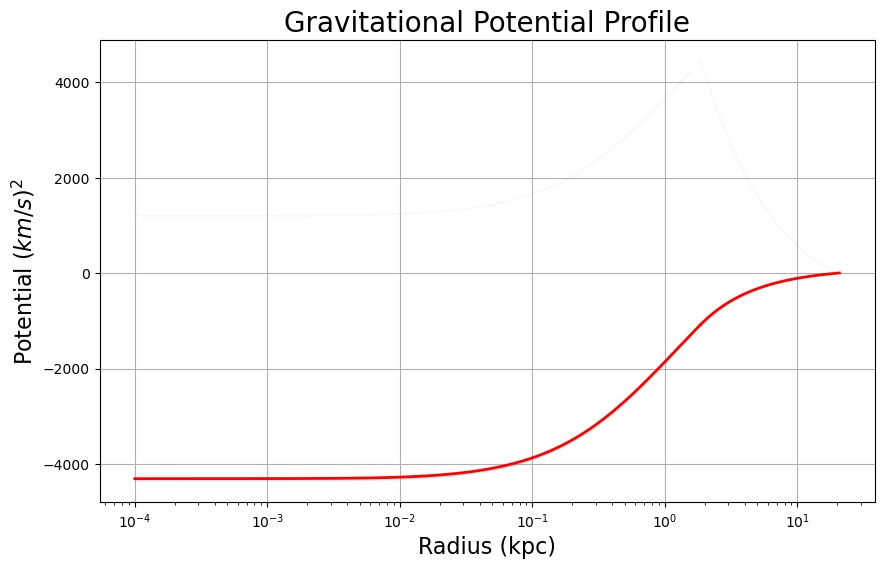

In [55]:
plt.figure(figsize=(10, 6))

kpc_to_km = 3.086e16

plt.title('Gravitational Potential Profile', fontsize=20)
for i in range(len(total_result['samples'])):
    plt.plot(r_to_rt[::10], np.array(total_result['samples'][i][0:50])*kpc_to_km**2, label='Gravitational Potential', color='grey', alpha=0.05)
    plt.plot(rt_to_end[::10], np.array(total_result['samples'][i][50:])*kpc_to_km**2, color='grey', alpha=0.05)
plt.plot(r_to_rt, np.array(total_result['mean'][0][0:500])*kpc_to_km**2, label='Gravitational Potential', color='red', linewidth=2)
plt.plot(rt_to_end, np.array(total_result['mean'][0][500:])*kpc_to_km**2, color='red', linewidth=2)
plt.xlabel('Radius (kpc)', fontsize=16)
plt.ylabel('Potential $(km/s)^2$', fontsize=16)
plt.xscale('log')
plt.grid()
plt.show()

# Wavefunction construction

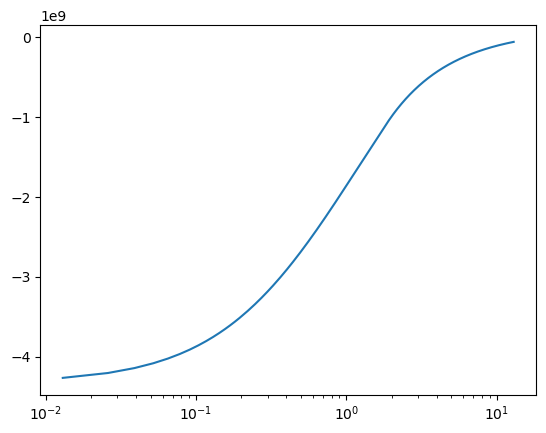

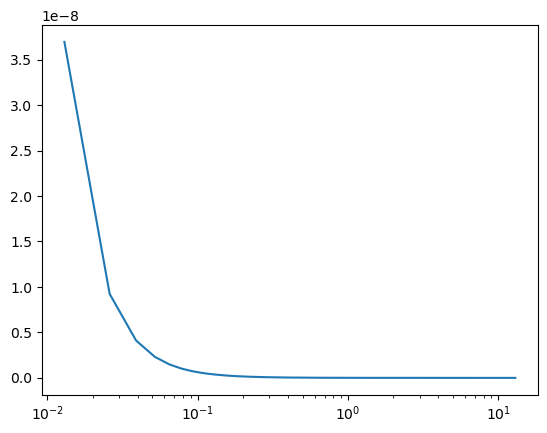

/tmp/ipykernel_3324065/3633014905.py:68: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm = np.sqrt(np.trapz(u * u, ri))


 mode_index  E (eigenvalue)
          0    3.723245e-13
          1    1.100509e-12
          2    2.192542e-12
          3    3.648524e-12
          4    5.468461e-12


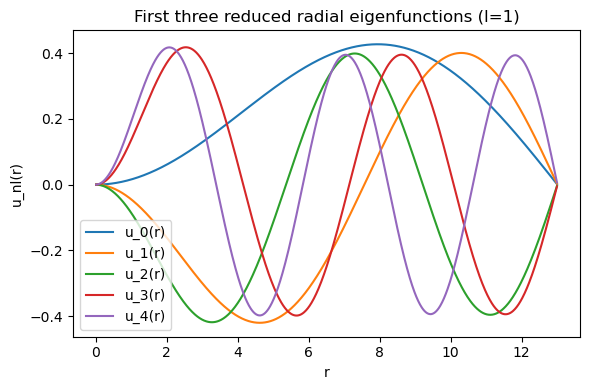

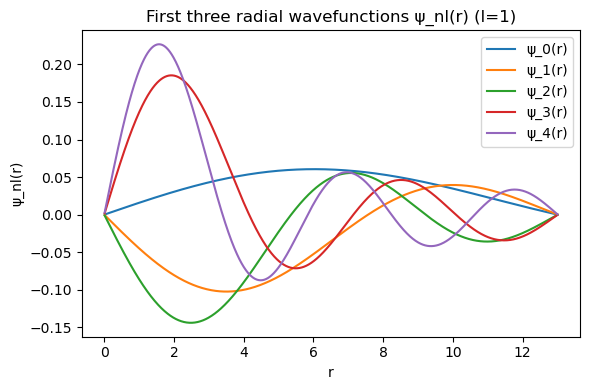

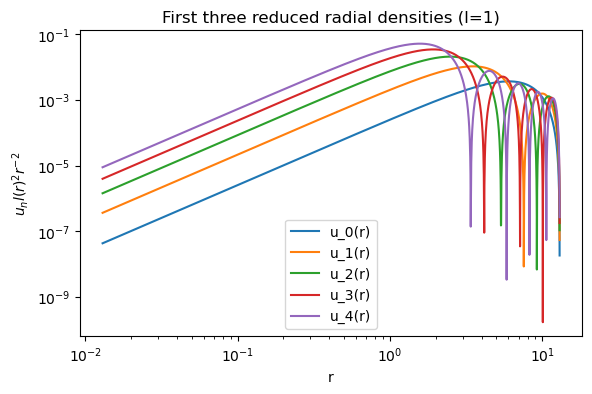

In [53]:
# Toy finite-difference eigenproblem for the radial Schrödinger equation
# We build H_l and compute its eigenvalues/eigenvectors to form an eigen-state library.
#
# Equation (units ħ=1, m=1):
#   -1/2 (d^2/dr^2 - l(l+1)/r^2) u(r) + V(r) u(r) = E u(r)
# with boundary conditions u(0)=0, u(R)=0.
#
# Default example: harmonic oscillator V(r) = (1/2) * ω^2 * r^2.
# Change l, R, N, or V_r to explore other cases.

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

ev_to_kg = 1.78266192e-36  # kg/eV     # m/kpc
kpc_to_m = 3.086e19  # m/kpc

# ----- Parameters -----
ħ = const.hbar  # J·s
m = 1e-21 *  ev_to_kg  # particle mass (kg)
l = 1 # angular momentum quantum number
R = 7*r_t # radial box size (maximum r) 
N = 1002     # number of grid points (including boundaries)

# ----- Grid -----
r = np.linspace(0, R, N)
dr = r[1] - r[0]


# Interior points (we enforce Dirichlet at r=0 and r=R)
ri = r[1:-1]
M = ri.size

# ----- Finite-difference second derivative (central differences) -----
diag = -2.0 * np.ones(M)
off = 1.0 * np.ones(M - 1)
D2 = (np.diag(diag) + np.diag(off, 1) + np.diag(off, -1)) / (dr**2)

# ----- Kinetic term -----
T = -(ħ**2) / (2.0 * m) * D2

# ----- Potential term (including centrifugal barrier) -----
# Swap this out for other potentials as needed.
V_r = np.array(total_result['mean'][0]) # in (kpc/s)^2
f_first = interp1d(r_to_rt, V_r[0:500], kind='cubic', fill_value="extrapolate")
f_last = interp1d(rt_to_end, V_r[500::], kind='cubic', fill_value="extrapolate")
V_r = np.concatenate((f_first(ri[ri <= r_t]), f_last(ri[ri > r_t])))
plt.plot(ri, V_r * kpc_to_m**2)
plt.xscale('log')
plt.show()

V_cent = (ħ**2) / (2.0 * m) * l * (l + 1) / (ri**2)

plt.plot(ri, V_cent)
plt.xscale('log')
plt.show()

V_eff = V_r + V_cent

# Hamiltonian H_l
H = T + np.diag(V_eff)

# ----- Eigen-decomposition -----
E, U = np.linalg.eigh(H)  # E sorted ascending, U columns are eigenvectors

# Normalise eigenvectors with respect to ∫|u|^2 dr = 1 on [0,R]
def normalize(u):
    norm = np.sqrt(np.trapz(u * u, ri))
    return u / norm

U_norm = np.column_stack([normalize(U[:, i]) for i in range(U.shape[1])])

# ----- Build a small "eigen-state library" -----
K = 5                 # number of lowest modes to keep
E_K = E[:K]
U_K = U_norm[:, :K]

# Show/save eigenvalues
df = pd.DataFrame({"mode_index": np.arange(K), "E (eigenvalue)": E_K})
print(df.to_string(index=False))
df.to_csv("radial_schrodinger_eigs_l0.csv", index=False)

# ----- Plot u_nl(r) for first few modes -----
plt.figure(figsize=(6, 4))
for i in range(K):
    plt.plot(ri, U_K[:, i], label=f"u_{i}(r)")
plt.xlabel("r")
plt.ylabel("u_nl(r)")
plt.title(f"First three reduced radial eigenfunctions (l={l})")
plt.legend()
plt.tight_layout()
plt.show()

# ----- Convert to ψ_nl(r) = u_nl(r) / r and plot (avoid r=0 by using interior grid) -----
psi_K = U_K / ri[:, None]
plt.figure(figsize=(6, 4))
for i in range(K):
    plt.plot(ri, psi_K[:, i], label=f"ψ_{i}(r)")
plt.xlabel("r")
plt.ylabel("ψ_nl(r)")
plt.title(f"First three radial wavefunctions ψ_nl(r) (l={l})")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
for i in range(K):
    plt.plot(ri, (U_K[:, i])**2 * 1/ (ri**2), label=f"u_{i}(r)")
plt.xlabel("r")
plt.ylabel(r"$u_nl(r)^2r^{-2}$")
plt.title(f"First three reduced radial densities (l={l})")
plt.legend()
plt.tight_layout()
plt.yscale('log')
plt.xscale('log')
plt.show()

NameError: name 'H' is not defined